# 加载数据集

图片像素信息在各端的不一致情况。

In [2]:

from torch.utils.data import DataLoader
from torchvision import datasets

full_dataset = datasets.ImageFolder("datasets/train")
print("loaded full dataset...")
print("总样本数:", len(full_dataset))
print("类别:", full_dataset.classes)
print("类别映射:", full_dataset.class_to_idx)



loaded full dataset...
总样本数: 24993
类别: ['Cat', 'Dog']
类别映射: {'Cat': 0, 'Dog': 1}


In [3]:
import time

start = time.time()

img, label = full_dataset[0]

print("读取耗时:", time.time() - start)
print("图片类型:", type(img))
print("图片尺寸:", img.shape if hasattr(img, "shape") else img.size)
print("label:", label)

读取耗时: 0.012561321258544922
图片类型: <class 'PIL.Image.Image'>
图片尺寸: (500, 375)
label: 0


In [ ]:
import matplotlib

print(matplotlib.get_backend())
print(matplotlib.get_backend())

import matplotlib.pyplot as plt

plt.figure()
plt.plot([1, 2, 3, 4])
plt.show()
#
# import matplotlib.pyplot as plt
#
# img, label = full_dataset[0]
#
# print("准备显示")
#
# plt.imshow(img)
# plt.axis("off")
# plt.show()
#
# print("显示完成")

module://matplotlib_inline.backend_inline
module://matplotlib_inline.backend_inline


In [1]:
import random
import matplotlib.pyplot as plt

# 随机找8个脚标
indices = random.sample(range(len(full_dataset)), 8)
# 定义2*4画布
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
# 循环散入数据
for ax, idx in zip(axes.flat, indices):
    img, label = full_dataset[idx]

    ax.imshow(img)
    ax.set_title(
        f"label={label} ({full_dataset.classes[label]})"
    )
    ax.axis("off")
plt.tight_layout()
plt.show()
print("show random eight picture done ....")

NameError: name 'full_dataset' is not defined

In [15]:
from torchvision import transforms
import torch

seed = 42
generator = torch.Generator().manual_seed(seed)

train_indices = []
val_indices = []

for label in range(len(full_dataset.classes)):
    # 找到当前类别的所有样本下标
    indices = [
        i for i, target in enumerate(full_dataset.targets)
        if target == label
    ]

    # 随机打乱
    indices = torch.tensor(indices)
    indices = indices[torch.randperm(len(indices), generator=generator)].tolist()

    # 80%训练，20%验证
    split = int(0.8 * len(indices))

    # 这里存储的是原始图片的index
    train_indices.extend(indices[:split])
    val_indices.extend(indices[split:])
print("split dataset to train and val done.")

from collections import Counter

train_labels = [full_dataset.targets[i] for i in train_indices]
val_labels = [full_dataset.targets[i] for i in val_indices]

print("训练集:")
print(Counter(train_labels))

print("验证集:")
print(Counter(val_labels))


split dataset to train and val done.
训练集:
Counter({1: 9999, 0: 9995})
验证集:
Counter({1: 2500, 0: 2499})


In [16]:
from torch.utils.data import Subset

print("begin create dataset...")
# 1、resize修改尺寸了，怎么判断应该改到什么尺寸？如果原图尺寸不够怎么办？
# 答：主要根据两个因素，模型的输入要求/常见的输入尺寸；任务对图像细节的要求。resnet一般都是224*224.如果原图小于这个尺寸，那么像素将会增加，原细节并未增多。这是一个信息量和计算量之间的权衡。
# 2. 怎么判断normalize里面的值，它是固定的么？
# 答： 基本上是固定的，这个数据是ImageNetRGB通道的均值和标准差。因为使用ImageNet的预训练参数，所以也采用对应的均值和标准差。
# 当然也可以自己计算得出：计算方法，先toTensor变成0~1的数值区间，会得到三个，RGB通道各一个。与之对应的就是三个均值，三个标准差。
# 如果使用预训练模型就用人家的。如果从零开始训练，就可以自己算
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# 因为full_dataset没有transform，train和val要用不同的tranform，所以需要单独创建两个单独的ImageFolder，然后再通过脚标索引去使用它
train_full = datasets.ImageFolder(
    "datasets/train",
    transform=train_transform
)
val_full = datasets.ImageFolder(
    "datasets/train",
    transform=val_transform
)

# Subset本质上做的就是
# train_full是一个玩真正的ImageFolder数据集 train_indices是索引编号，然后靠Subset构建出一个某一块数据集，
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)
print("create two datasets done")

begin create dataset...
create two datasets done


In [17]:
# 创建dataloader
batch_size = 64
print("begin create dataloader")
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 代表每个epoch都打乱顺序
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)
# 获取一个batchsize数据，然后展示数据的星霜
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print("create dataLoader done")

begin create dataloader
torch.Size([64, 3, 224, 224])
torch.Size([64])
create dataLoader done


# 模型选择与创建
这里只有猫狗两个类别，也就是二分类。属于简单分类，先用ResNet18


In [ ]:
import torch
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用 {device} 进行训练")
model = models.resnet18(
    weights=models.ResNet18_Weights)

print("change nn linear")
# 因为这个项目是二分类，所以全连接输出层需要修改（ResNet默认100分类）
from torch import nn

model.fc = nn.Linear(
    model.fc.in_features,  #
    2
)
model = model.to(device)
print("create model done")
print(model.fc)

# 定义损失函数和迭代器


In [ ]:
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=1e-4
)
print("define loss and optim done")

# 开始训练

In [4]:
import os

running_loss = 0.0
correct = 0
total = 0

# 这里loader已经设置了批量的大小，所以这里相当于next，每次都会取出固定批次数据
print("begin train")
num_epochs = 10

best_val_acc = 0.0
best_model_path = "best_ResNet18.pth"
checkpoint_path = "checkpoint_ResNet18.pth"
start_epoch = 0

if os.path.exists(checkpoint_path):
    # 检查有没有check_point,如果有加载
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    print(f"从{start_epoch}开始训练")

for epoch in range(start_epoch, num_epochs):
    # 设置训练模式
    model.train()
    # 当前 epoch 的统计量
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        #1. 清空上一轮梯度：清除model.parameter.gard的值
        optimizer.zero_grad()

        #2. 前向传播，即开始预测
        outputs = model(images)

        #3. 计算损失loss
        loss = criterion(outputs, labels)

        # 4. 反向传播:从 loss 开始，沿着计算图反向计算每一个参数对 loss 的梯度。
        # loss 是一个 Tensor，autograd 通过计算图记录 loss 与模型参数之间的计算依赖关系。
        # backward() 沿计算图反向计算 loss 对模型参数的梯度，并写入 parameter.grad。
        loss.backward()

        # 5. 更新模型参数:用刚才计算的梯度去更新参数。根据model.parameter.gard的值去更新model.parameter
        optimizer.step()

        # 统计loss
        running_loss += loss.item()

        # 统计准确率
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # 当前 epoch 的平均 loss 和 accuracy
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # 设置验证模式
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        # 标识以下操作均不进行梯度计算
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            #1. 前向传播
            outputs = model(images)

            #2.计算损失loss
            loss - criterion(outputs, labels)

            #3. 统计loss
            val_running_loss += loss.item()

            #统计准确率
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    # 统计当前epoch的验证集loss和accuracy
    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "epoch": epoch,
                "model_name": "resnet18",
                "class_to_idx": full_dataset.class_to_idx,

                "model_state_dict": model.state_dict(),

                "best_val_acc": best_val_acc,

                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,

                "batch_size": batch_size,
                "learning_rate": 1e-4,
            },
            best_model_path
        )
        print(f"保存最佳模型 {best_val_acc:.4f}")
        # 保存当前的模型
        torch.save(
            {
                "epoch": epoch,
                "model_name": "resnet18",
                "class_to_idx": full_dataset.class_to_idx,

                "model_state_dict": model.state_dict(),

                "best_val_acc": best_val_acc,

                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,

                "batch_size": batch_size,
                "learning_rate": 1e-4,
            },
            best_model_path
        )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )


begin train


NameError: name 'model' is not defined

# 加载模型，开始推理

In [7]:
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)
model.fc = nn.Linear(
    model.fc.in_features,
    2
)
model = model.to(device)
print("加载模型")
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
#加载分类名称和对应索引
class_to_idx = checkpoint["class_to_idx"]

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}
print("当前加载的类别信息为")
print(idx_to_class)

print("模型加载成功")
print(f"最佳验证准确率: ",checkpoint["best_val_acc"])

# 加载和训练过程中 val相同的transform
from torchvision import transforms

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def predict(image_paths, model, transform, idx_to_class, device):
    """
    对一批没有标签的图片进行预测。

    参数：
        image_paths: 图片路径列表
        model: 已加载好的模型
        transform: 推理阶段的 transform
        idx_to_class: 类别索引 -> 类别名称
        device: cpu / cuda

    返回：
        results: 每张图片的预测结果
    """

    model.eval()

    results = []

    # =========================
    # 1. 读取并预处理所有图片
    # =========================

    tensors = []

    for image_path in image_paths:
        image = Image.open(image_path).convert("RGB")

        tensor = transform(image)

        tensors.append(tensor)

    # =========================
    # 2. 拼成 Batch
    # =========================

    batch = torch.stack(tensors)

    batch = batch.to(device)

    # =========================
    # 3. 批量推理
    # =========================

    with torch.no_grad():

        outputs = model(batch)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

    # =========================
    # 4. 整理结果
    # =========================

    for image_path, prediction, confidence in zip(
            image_paths,
            predictions,
            confidences
    ):
        prediction = prediction.item()
        confidence = confidence.item()

        results.append({
            "path": image_path,
            "class": idx_to_class[prediction],
            "confidence": confidence
        })

    return results

image_paths = [
    "datasets/test/OIP.jpg",
    "datasets/test/OIP2.jpg",
    "datasets/test/OIP3.jpg",
    "datasets/test/dog.jpg",
]
results = predict(image_paths, model, inference_transform, idx_to_class, device)
for result in results:
    print(result)

加载模型
当前加载的类别信息为
{0: 'Cat', 1: 'Dog'}
模型加载成功
最佳验证准确率:  0.9895979195839167
{'path': 'datasets/test/OIP.jpg', 'class': 'Cat', 'confidence': 0.9998821020126343}
{'path': 'datasets/test/OIP2.jpg', 'class': 'Cat', 'confidence': 0.9999796152114868}
{'path': 'datasets/test/OIP3.jpg', 'class': 'Cat', 'confidence': 0.9999998807907104}
{'path': 'datasets/test/dog.jpg', 'class': 'Dog', 'confidence': 0.9999997615814209}


# 模型导出
.pth是pytorch模型参数，.onnx是模型的计算图+参数

In [13]:
import torch
import torch.nn as nn
from torchvision import models
# 加载模型
print("load model")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)
model.fc = nn.Linear(
    model.fc.in_features,
    2
)
model = model.to(device)
print("加载模型")
checkpoint = torch.load(
    "best_ResNet18.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()
print("模型加载成功")
print(f"最佳验证准确率: ",checkpoint["best_val_acc"])

load model
加载模型
模型加载成功
最佳验证准确率:  0.9895979195839167


In [7]:
import torch.onnx
# 确保是推理模式
model.eval()
onnx_path = "cat_dog_resnet18.onnx"

# 这行代码的目的是  用一个假数据让模型实际走一遍，作为示例。在后面的导出方法中，导出器会根据示例去追踪/构建模型的计算图，并根据这个生成ONNX图。这个示例不是模型的一部分，也不会参与后续推理，所以是一个随机数
dummy_input = torch.randn(
    1, 3, 224, 224
).to(device)

# 生成两个文件：1、onnx：模型图、输入输出信息、算子信息、模型结构 2、onnx.data：模型中大块张量数据，权重参数等
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,

    # 给输入输出起名字
    input_names=["images"],
    output_names=["outputs"],

    # 这个配置用来告诉导出器我有哪些维度是动态的；输入 Batch 和输出 Batch 必须保持对应关系。
    dynamic_axes={
        "images": {
            0: "batch_size" # 标识第0维是batch_size并且可以动态变化
        },
        "outputs": {
            0: "batch_size"
        }
    },

    # ONNX 算子集版本
    opset_version=17
)


C:\Users\22035483\AppData\Local\Temp\ipykernel_9644\2948309882.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0826 12:19:46.880000 9644 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\22035483\.conda\envs\test311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "C:\Users\22035483\.conda\envs\test311\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\22035483\.conda\envs\test311\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "C:\Users\22035483\.conda\envs\test311\Lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\22035483\.conda\envs\test311\Lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
             

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.13.0+cu126',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"images"<FLOAT,[batch_size,3,224,224]>
            ),
            outputs=(
                %"outputs"<FLOAT,[batch_size,2]>
            ),
            initializers=(
                %"fc.bias"<FLOAT,[2]>{TorchTensor<FLOAT,[2]>(Parameter containing: tensor([-0.0346, -0.0185], device='cuda:0', requires_grad=True), name='fc.bias')},
                %"conv1.weight"<FLOAT,[64,3,7,7]>{Tensor(...)},
                %"layer1.0.conv1.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.0.conv2.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.1.conv1.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.1.conv2.weight"<FLOAT,[64,64

# 使用onnx推理

In [10]:
#加载模型
import onnxruntime as ort

onnx_path = "cat_dog_resnet18.onnx"

session = ort.InferenceSession(
    onnx_path,
    providers=["CPUExecutionProvider"]
)

print("ONNX 模型加载成功")

inputs = session.get_inputs()
outputs = session.get_outputs()

for input_info in inputs:
    print("输入名称:", input_info.name)
    print("输入 shape:", input_info.shape)
    print("输入类型:", input_info.type)
for output_info in outputs:
    print("输出名称:", output_info.name)
    print("输出 shape:", output_info.shape)
    print("输出类型:", output_info.type)
print("load onnx done")

ONNX 模型加载成功
输入名称: images
输入 shape: ['batch_size', 3, 224, 224]
输入类型: tensor(float)
输出名称: outputs
输出 shape: ['batch_size', 2]
输出类型: tensor(float)
load onnx done


In [12]:
from torchvision import  transforms
device = "cuda"
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
image_paths = [
    "datasets/test/OIP.jpg",
    "datasets/test/OIP2.jpg",
    "datasets/test/OIP3.jpg",
    "datasets/test/dog.jpg",
]
tensors = []

for image_path in image_paths:
    image = Image.open(image_path).convert("RGB")

    tensor = inference_transform(image)

    tensors.append(tensor)

# =========================
# 2. 拼成 Batch
# =========================

batch = torch.stack(tensors)

# batch = batch.to(device)
print("Batch shape:", batch.shape)

onnx_input = batch.numpy()

onnx_output = session.run(
    ["outputs"],
    {
        "images": onnx_input
    }
)[0]
print("ONNX output:")
print(onnx_output)
import numpy as np

exp_output = np.exp(onnx_output)

probabilities = (
    exp_output /
    exp_output.sum(axis=1, keepdims=True)
)

print(probabilities)

Batch shape: torch.Size([4, 3, 224, 224])
ONNX output:
[[ 4.0433154 -5.002718 ]
 [ 4.7949996 -6.008399 ]
 [ 7.3132277 -8.738016 ]
 [-7.669772   7.5964913]]
[[9.9988210e-01 1.1784372e-04]
 [9.9997967e-01 2.0329879e-05]
 [9.9999994e-01 1.0691371e-07]
 [2.3439370e-07 9.9999976e-01]]


# 混淆矩阵模块
每次识别有问题的时候，不能光看准确率。我们还有知道为什么错，通常我们需要问以下几个问题：
1. 错在哪里？ 混淆矩阵
2. 每个类别表现怎么样？ precision/recall/F1
3. 具体错的是哪些图片？错误样本可视化

In [26]:
from torch.utils.data import Dataset


class IndexedSubset(Dataset):

    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]

        # 映射到原始 ImageFolder 的索引
        original_idx = self.subset.indices[idx]

        return image, label, original_idx
indexed_val_dataset = IndexedSubset(val_dataset)

indexed_val_loader = DataLoader(
    indexed_val_dataset,
    batch_size=32,
    shuffle=False
)

In [31]:
#设定模型为评估模式
model.eval()

# 建立三个列表
all_labels = []
all_predictions = []
wrong_samples = [] #记录错误数据的信息

with torch.no_grad():

    for images, labels, original_indices in indexed_val_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 模型输出 logits
        outputs = model(images)

        #计算置信度
        probabilities = torch.softmax(outputs, dim=1)
        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

        # 找到 logit 最大的类别
        _, predictions = torch.max(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

        for i in range(len(labels)):
            if predictions[i] != labels[i]:
                wrong_samples.append({
                    "index": original_indices[i].item(),
                    "true": labels[i].item(),
                    "pred": predictions[i].item(),
                    "confidence": confidences[i].item()
                })

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)
print(len(wrong_samples))


[[2482   17]
 [  35 2465]]
52


# 参数怎么看
Precision： 模型说这是类别A的时候，准不准？

recall： 真实类别A的所有个体中，模型找出来多少个？

F1： precision和recall综合起来怎么样

support: 在验证集中每种类别的数量


In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=full_dataset.classes
    )
)

              precision    recall  f1-score   support

         Cat       0.99      0.99      0.99      2499
         Dog       0.99      0.99      0.99      2500

    accuracy                           0.99      4999
   macro avg       0.99      0.99      0.99      4999
weighted avg       0.99      0.99      0.99      4999



# 错误样本分析
把模型预测错误的照片找出来，看它为什么错。

原始索引: 380
真实类别: Cat
预测类别: Dog
置信度: 0.6829


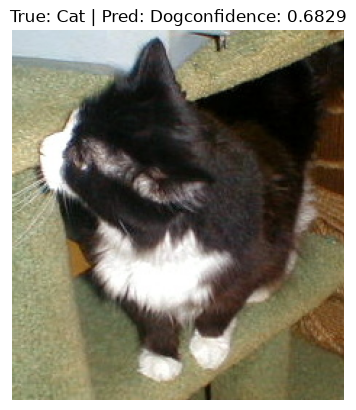

In [35]:
# 看一个图片
wrong = wrong_samples[0]

index = wrong["index"]

image, label = full_dataset[index]

print("原始索引:", index)
print("真实类别:", full_dataset.classes[label])
print("预测类别:", full_dataset.classes[wrong["pred"]])
print(f"置信度: {wrong['confidence']:.4f}")
import matplotlib.pyplot as plt

plt.imshow(image)

plt.title(
    f"True: {full_dataset.classes[label]} | "
    f"Pred: {full_dataset.classes[wrong['pred']]}"
    f"confidence: {wrong['confidence']:.4f}"
)

plt.axis("off")
plt.show()

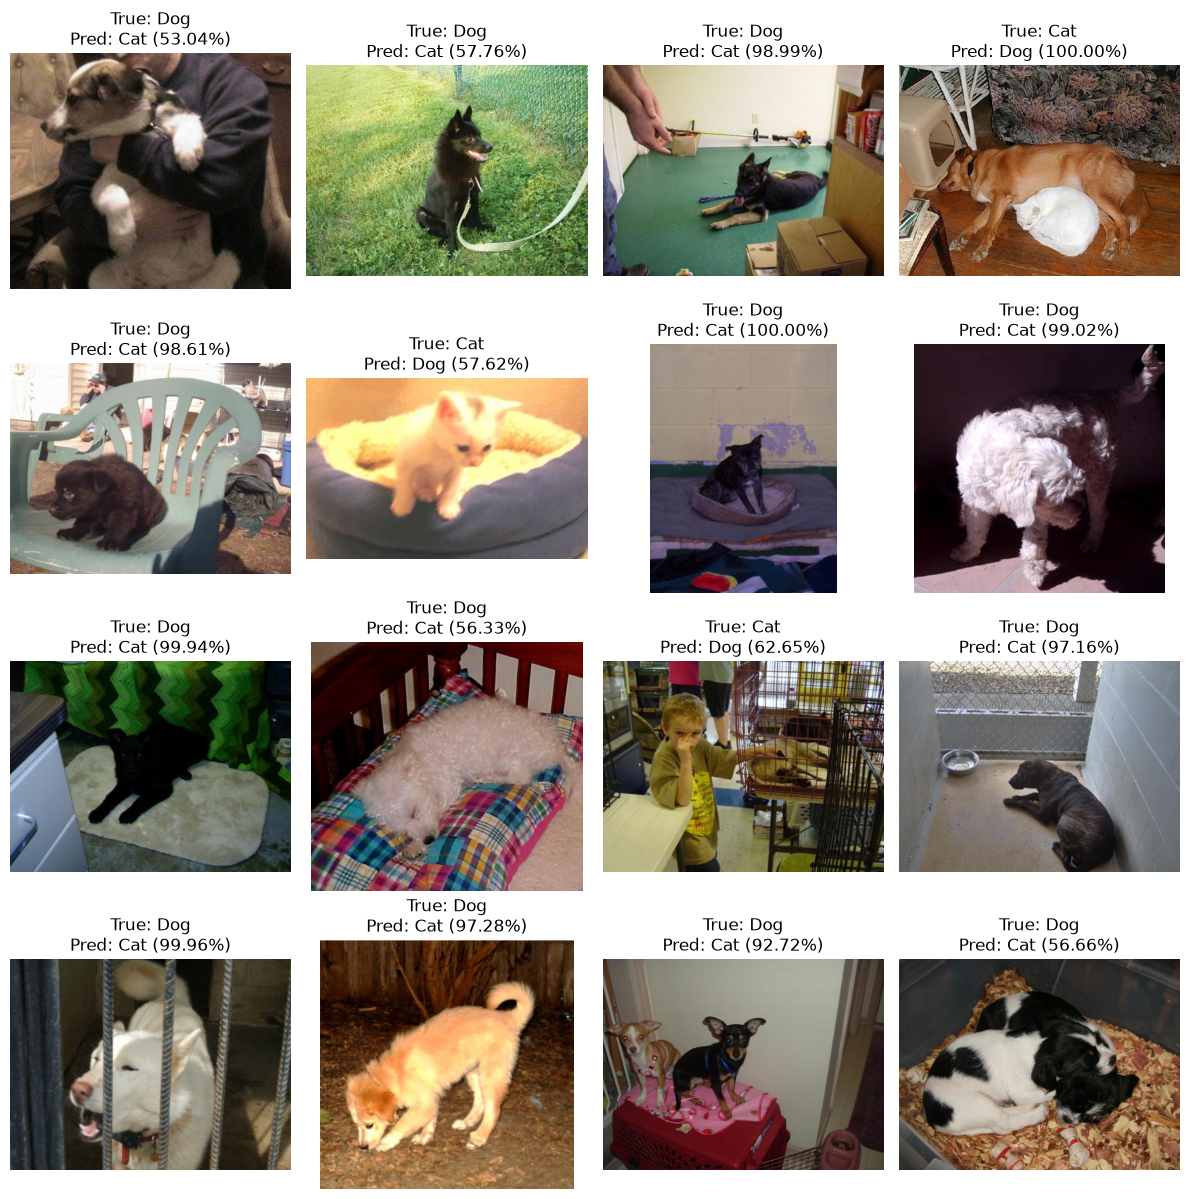

In [36]:
import random

show_num = min(16, len(wrong_samples))

samples_to_show = random.sample(
    wrong_samples,
    show_num
)
import matplotlib.pyplot as plt

cols = 4
rows = (show_num + cols - 1) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(12, 3 * rows)
)

# 防止只有一行/一张图片时 axes 不是一维数组
axes = axes.flatten()

for ax, sample in zip(axes, samples_to_show):

    image, true_label = full_dataset[
        sample["index"]
    ]

    true_class = full_dataset.classes[
        sample["true"]
    ]

    pred_class = full_dataset.classes[
        sample["pred"]
    ]

    confidence = sample["confidence"]

    ax.imshow(image)

    ax.set_title(
        f"True: {true_class}\n"
        f"Pred: {pred_class} "
        f"({confidence:.2%})"
    )

    ax.axis("off")

# 如果最后有空白位置，把它们关掉
for ax in axes[show_num:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 分析错误内容
一般来说问题主要发生在以下场景：
1. 图片本身很难：光线暗、严重遮挡、图片模糊。 解决方案：数据本身很难，这种很难解决
2. 数据标签错误：实际图片和真实标签不符。解决方案：更新标签，如果是大规模的错误，可能要重新训练
3. 数据分布问题：如果训练集里面都是室内猫+室外狗。那么模型最后最后可能认为室内=猫、室外=狗 ，模型识别到假线索，典型的数据偏差问题（捷径学习shortcut）。解决方案：均匀数据分布
4.模型没学好：图片清晰、猫狗主体明显、标签没问题。

# 检查高置信度错误
我们要看模型识别错误的数据中，最自信的是哪些图片，并且分析原因。

[{'index': 13465, 'true': 1, 'pred': 0, 'confidence': 0.9999997615814209}, {'index': 10185, 'true': 0, 'pred': 1, 'confidence': 0.9999992847442627}, {'index': 18700, 'true': 1, 'pred': 0, 'confidence': 0.9999991655349731}, {'index': 7339, 'true': 0, 'pred': 1, 'confidence': 0.999983549118042}, {'index': 21956, 'true': 1, 'pred': 0, 'confidence': 0.9997655749320984}, {'index': 17945, 'true': 1, 'pred': 0, 'confidence': 0.9995855689048767}, {'index': 23266, 'true': 1, 'pred': 0, 'confidence': 0.9994375109672546}, {'index': 20372, 'true': 1, 'pred': 0, 'confidence': 0.9955530762672424}, {'index': 960, 'true': 0, 'pred': 1, 'confidence': 0.9928192496299744}, {'index': 17794, 'true': 1, 'pred': 0, 'confidence': 0.9902395009994507}]


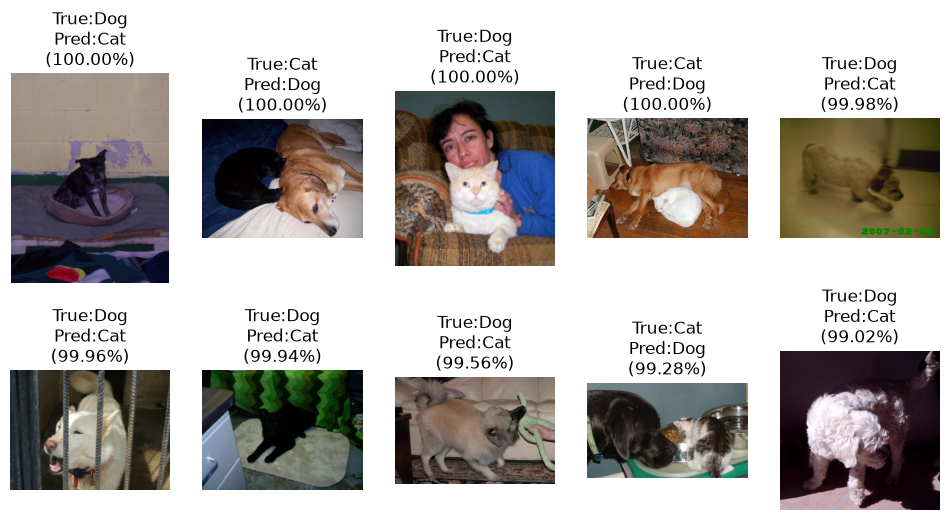

In [39]:
wrong_samples_sorted = sorted(
    wrong_samples,
    key=lambda x: x["confidence"],
    reverse=True
)
samples_to_show = wrong_samples_sorted[:10]
print(samples_to_show)
from matplotlib import pyplot as plt
cols = 5
rows=2
fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(12, 3 * rows)
)

# 关键：把 2×5 的 axes 展平成一维
axes = axes.flatten()

for ax, sample in zip(axes, samples_to_show):
    image, true_label = full_dataset[sample["index"]]
    #sample["true"]是类别编号
    true_class = full_dataset.classes[sample["true"]]

    pred_class = full_dataset.classes[sample["pred"]]

    confidence = sample["confidence"]
    ax.imshow(image)

    ax.set_title(
        f"True:{true_class}\n"
        f"Pred:{pred_class}\n"
        f"({confidence:.2%})"
    )
    ax.axis("off")


# 继续分析问题
通过我的肉眼看，确实有一部分是标签错误，或者角度太暗。但是有一部分是狗的不同角度，人眼可以分出来的。
这个时候针对这种场景，对其进行模型优化。如果说侧面不够，那么增加这个分类所有的侧面数据，否则还容易发生shortcut

# 分析应该补充什么数据
统计输出错误信息，这样可以有统计依据地决定到底应该补什么数据、清理什么数据。

In [42]:
from collections import Counter

# 统计真实类别 -> 预测类别
error_counts = Counter(
    (sample["true"], sample["pred"])
    for sample in wrong_samples
)

for (true_idx, pred_idx), count in error_counts.items():

    true_class = full_dataset.classes[true_idx]
    pred_class = full_dataset.classes[pred_idx]

    print(
        f"{true_class} -> {pred_class}: {count} 张"
    )

confidence_levels = {
    "90%~100%": 0,
    "70%~90%": 0,
    "50%~70%": 0
}

for sample in wrong_samples:

    confidence = sample["confidence"]

    if confidence >= 0.9:
        confidence_levels["90%~100%"] += 1

    elif confidence >= 0.7:
        confidence_levels["70%~90%"] += 1

    else:
        confidence_levels["50%~70%"] += 1


for level, count in confidence_levels.items():

    print(
        f"{level}: {count} 张"
    )

Cat -> Dog: 17 张
Dog -> Cat: 35 张
90%~100%: 24 张
70%~90%: 11 张
50%~70%: 17 张


从 **Cat -> Dog: 17 张 Dog -> Cat: 35 张**
我们看到模型存在明显的类别方向偏差（如果这些图片标签都是正常的前提下），狗被认错的数据量是猫被认错的两倍
结合我们的训练数据集中猫狗数据完全平衡，所以我们就要考虑以下问题：
1. 狗的视觉变化是不是比猫更复杂？
2. 狗的姿态角度是不是不全
3. 狗是不是存在容易被认成猫的场景
4. 猫的数据是不是更加统一？
5. 是不是存在背景、拍摄角度的shortcut？

Dog -> Cat 错误数量: 35
[{'index': 13465, 'true': 1, 'pred': 0, 'confidence': 0.9999997615814209}, {'index': 18700, 'true': 1, 'pred': 0, 'confidence': 0.9999991655349731}, {'index': 21956, 'true': 1, 'pred': 0, 'confidence': 0.9997655749320984}, {'index': 17945, 'true': 1, 'pred': 0, 'confidence': 0.9995855689048767}, {'index': 23266, 'true': 1, 'pred': 0, 'confidence': 0.9994375109672546}, {'index': 20372, 'true': 1, 'pred': 0, 'confidence': 0.9955530762672424}, {'index': 17794, 'true': 1, 'pred': 0, 'confidence': 0.9902395009994507}, {'index': 12613, 'true': 1, 'pred': 0, 'confidence': 0.9898979663848877}, {'index': 17892, 'true': 1, 'pred': 0, 'confidence': 0.9896230697631836}, {'index': 23354, 'true': 1, 'pred': 0, 'confidence': 0.9861382842063904}]


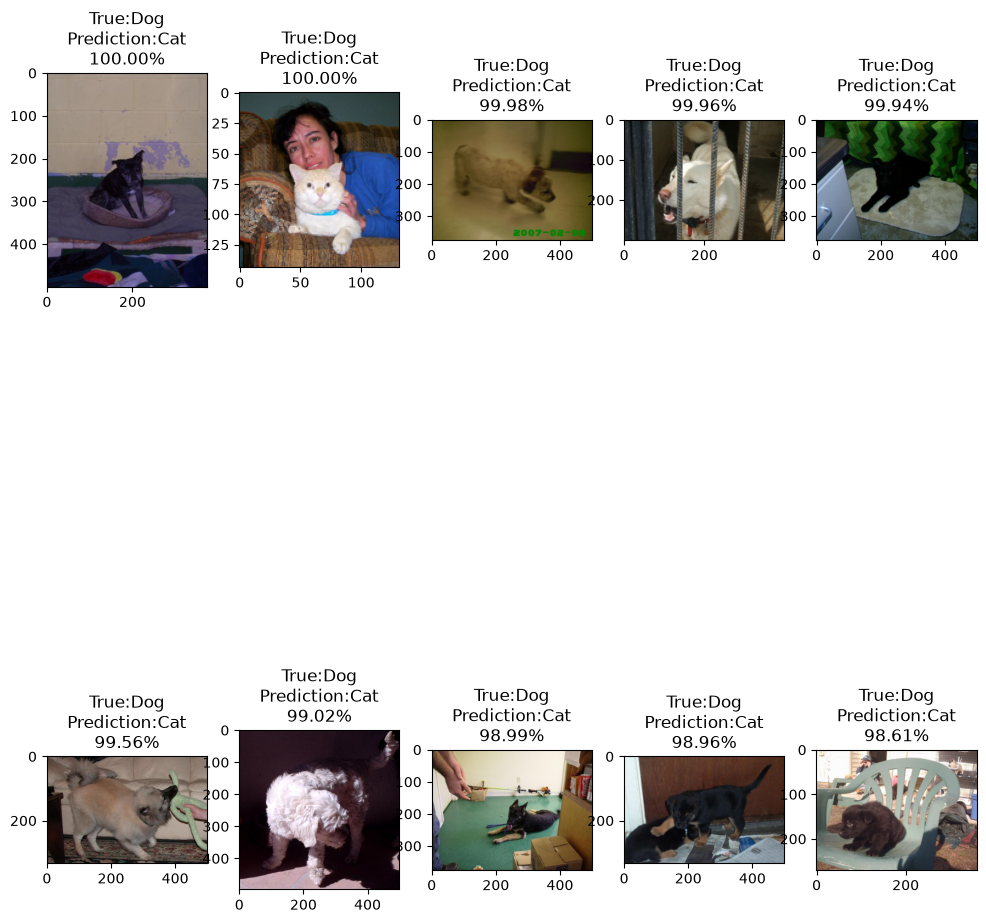

In [46]:
dog_to_cat = [
    sample
    for sample in wrong_samples
    if sample["true"] == full_dataset.class_to_idx["Dog"]
    and sample["pred"] == full_dataset.class_to_idx["Cat"]
]

print("Dog -> Cat 错误数量:", len(dog_to_cat))
dog_to_cat = sorted(
    dog_to_cat,
    key=lambda x: x["confidence"],
    reverse=True
)
print(dog_to_cat[:10])
# 打印图片
from matplotlib import pyplot as plt
cows = 5
rows =2
fig, axes = plt.subplots(rows,cows,figsize = (12,15))
axes = axes.flatten()
for ax ,sample in zip(axes, dog_to_cat):
    image,label = full_dataset[sample["index"]]
    ax.imshow(image)
    true_class = full_dataset.classes[sample["true"]]
    pred_class = full_dataset.classes[sample["pred"]]
    confidence = sample["confidence"]

    ax.set_title(
        f'True:{true_class}\n'
        f'Prediction:{pred_class}\n'
        f'{confidence:.2%}'
    )
